In [4]:
intro_images_path='./Images/Intro_images/'
edge_images_path='./Images/Edge_images/'
seg_images_path='./Images/Seg_images/'
feature_images_path='./Images/Feature_images/'
stereoi_images_path='./Images/StereoIntrinsic_images/'
stereodm_images_path='./Images/StereoDepthMask_images/'
output_images_path='./Images/Output_images/'

# Visión por Computador

**Grao en Intelixencia Artificial**

Curso 2025-26


<img src="./Logotipo_Solo.png" width=200/>


## Correspondencia estéreo dispersa

Podemos identificar puntos correspondentes entre dúas vistas dunha escena facendo simplemente unha estimación de correspondencias baseada nas características locais, sen ter enconta a xeometría epipolar.

In [5]:
!pip install opencv-python

In [6]:
import numpy as np
import cv2
import glob
import argparse
from matplotlib import pyplot as plt

In [7]:
def feature_pairs(matches,kp1,kp2):

    pt_img1 =np.array([kp1[match.queryIdx].pt for match in matches]).reshape(-1,2)
    pt_img2 = np.array([kp2[match.trainIdx].pt for match in matches]).reshape(-1,2) 

    return pt_img1,pt_img2


def feature_match(image1,image2,MAX_FEATURES=500):

        img1 = image1.copy()
        img2 = image2.copy()

        gray1 = cv2.cvtColor(img1,cv2.COLOR_BGR2GRAY)
        gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

        print("Detecting features")
        sift = cv2.SIFT_create(nfeatures=MAX_FEATURES) 

        kp1, des1 = sift.detectAndCompute(img1,None) 
        kp2, des2 = sift.detectAndCompute(img2,None)
        
        """
        orb = cv2.ORB_create()

        kp1,des1 = orb.detectAndCompute(gray1, None)
        kp2,des2 = orb.detectAndCompute(gray2, None)
        
        img_1=cv2.drawKeypoints(gray1,kp1,img1)
        img_2=cv2.drawKeypoints(gray2,kp2,img2)
        """

        print("Feature Matching")
        # create BFMatcher object 
        bf = cv2.BFMatcher(cv2.NORM_L1, crossCheck=True) 

        # Match features.    
        matches = bf.match(des1,des2)

        # Sort matches by score 
        matches = sorted(matches, key = lambda x:x.distance) 

        # Remove not so good matches 
        numGoodMatches = 50
        matches = matches[:numGoodMatches] 

     
        img3 = cv2.drawMatches(gray1,kp1,gray2,kp2,matches,None,flags=2)
        #cv2.imwrite('feature_match.png',img3)
        plt.imshow(img3)
        plt.xticks([]),plt.yticks([])
        plt.show()
        
        return matches,kp1,kp2


Total Number of images: 2


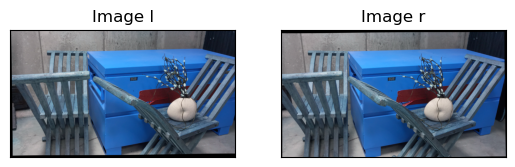

In [8]:
dataset="curule" 

if dataset=="curule":
    k1 = np.array([[1758.23,0, 977.42], [ 0, 1758.23, 552.15], [0 ,0, 1]])
    k2 = np.array([[1758.23,0 ,977.42], [0,1758.23 ,552.15], [0, 0, 1]])
    baseline=88.39
    f = k1[0,0]

if dataset=="octagon":
    k1 = np.array([[1742.11, 0 ,804.90], [0 ,1742.11 ,541.22], [0 ,0, 1]])
    k2 = np.array([[1742.11, 0 ,804.90], [0 ,1742.11, 541.22], [0, 0, 1]])
    baseline=221.76
    f = k1[0,0]

if dataset == "pendulum":
    k1 = np.array([[1729.05, 0 ,-364.24], [0 ,1729.05 ,552.22], [0 ,0, 1]])
    k2 = np.array([[1729.05, 0, -364.2], [0,1729.05, 552.22], [0, 0, 1]])
    baseline=537.75
    f = k1[0,0]
    
path = stereoi_images_path+ str(dataset)
images = [cv2.imread(file) for file in sorted(glob.glob(str(path)+'/*.png'))]
print("Total Number of images:", len(images))
image1 = images[0]
image2 =images[1]


plt.subplot(121),plt.imshow(image1)
plt.title('Image l'), plt.xticks([]), plt.yticks([])
plt.subplot(122),plt.imshow(image2)
plt.title('Image r'), plt.xticks([]), plt.yticks([])
plt.show()



Detecting features
Feature Matching


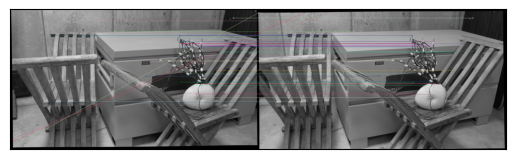

In [9]:
'''
feature detection and matching
'''
matches,key_features1,key_features2 = feature_match(image1,image2)
pt1,pt2  = feature_pairs(matches,key_features1,key_features2) 

## EXERCICIO 4.1 (x.x puntos):

Considerade calquera dos pares de vistas previos, tomadas con cámaras con planos imaxe paralelos e separadas por unha liña base descoñecida. Usando os datos de calibración da cámara e a correspondencia de puntos entre as dúas vistas:  
(1) filtra correspondencias que son necesariamente erróneas en base a xeometria epipolar;  
(2) crea unha función que devolva unha estimación da liña base con datos de precisión (a partir da correspondencia de varios puntos, e polo tanto a disparidade); despois  
(3) crea outra función para estimar a distancia a un punto da escena tomando como dato un par de puntos correspondentes (xa coñeces todos os parámetros necesarios).

---
---

Correspondencias orixinais: 50
Correspondencias despois do filtrado: 46


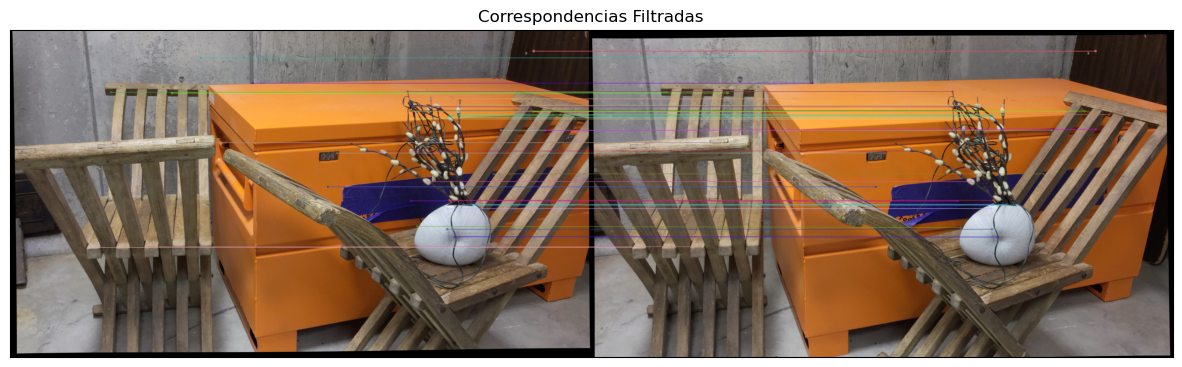

In [10]:
# Os datos do conxunto curule xa cargados 
# incluíndo as correspondencias de puntos pt1 e pt2, 
# e parámetros intrínsecos da cámara k1, k2, a distancia focal f e a liña base real baseline.

def filtrar_correspondencias_epipolar(pt1, pt2, umbral_y=5.0):
    puntos_filtrados1 = []
    puntos_filtrados2 = []
    indices_mantidos = []
    
    for i in range(len(pt1)):
        # Comprobar se a diferenza absoluta na coordenada 'y' está dentro do umbral
        if abs(pt1[i, 1] - pt2[i, 1]) < umbral_y:
            puntos_filtrados1.append(pt1[i])
            puntos_filtrados2.append(pt2[i])
            indices_mantidos.append(i)
            
    print(f"Correspondencias orixinais: {len(pt1)}")
    print(f"Correspondencias despois do filtrado: {len(puntos_filtrados1)}")
    
    return np.array(puntos_filtrados1), np.array(puntos_filtrados2)

# Aplicar a función de filtrado
pt1_filtrados, pt2_filtrados = filtrar_correspondencias_epipolar(pt1, pt2, umbral_y=5.0)

# Visualizar 
matches_filtrados = [matches[i] for i in range(len(matches)) if abs(key_features1[matches[i].queryIdx].pt[1] - key_features2[matches[i].trainIdx].pt[1]) < 5.0]

img_matches_filtrados = cv2.drawMatches(image1, key_features1, image2, key_features2, matches_filtrados, None, flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
plt.figure(figsize=(15, 5))
plt.imshow(cv2.cvtColor(img_matches_filtrados, cv2.COLOR_BGR2RGB))
plt.title("Correspondencias Filtradas")
plt.xticks([]), plt.yticks([])
plt.show()

O resultado mostra que se pasou de 50 a 46 correspondencias.  
Esta pequena redución (só se eliminaron 2 pares) indica que o algoritmo de correspondencia de características inicial (SIFT + BFMatcher) xa era moi preciso.  
Ademais a visualización amosa liñas case perfectamente horizontais grazas á calidade do dataset.

In [ ]:
def estimar_lina_base(puntos1, puntos2, k1, k2):
    # Estimar a matriz Esencial usando os puntos filtrados e os parámetros intrínsecos
    E, _ = cv2.findEssentialMat(puntos1, puntos2, k1, method=cv2.RANSAC, prob=0.999, threshold=1.0)
    
    # Recuperar a pose (rotación e translación) da matriz Esencial
    # A función devolve a solución correcta despois da verificación de quiralidade (cheirality check)
    _, R, T, _ = cv2.recoverPose(E, puntos1, puntos2, k1)
    
    return T, R

# Estimar a liña base usando os puntos filtrados
T_estimado, R_estimada = estimar_lina_base(pt1_filtrados, pt2_filtrados, k1, k2)

print("Liña base estimada (vector de translación normalizado T):\n", T_estimado)
print("\nMatriz de rotación estimada R:\n", R_estimada)

Liña base estimada (vector de translación normalizado T):
 [[-0.99915969]
 [-0.0125777 ]
 [ 0.03900918]]

Matriz de rotación estimada R:
 [[ 9.99842176e-01 -4.06758697e-03  1.72938477e-02]
 [ 4.06086059e-03  9.99991665e-01  4.24045371e-04]
 [-1.72954284e-02 -3.53750542e-04  9.99850360e-01]]

Nota: A magnitude do vector de translación T está normalizada a 1.
A liña base real do dataset 'curule' é de 88.39 mm, que representa o factor de escala.


A rotación relativa debería ser practicamente nula, e a translación debería ocorrer principalmente ao longo do eixe X,  
que é o que reflicte o vector T (o compoñente X é case -1, mentres que os outros son case 0).

In [12]:
def estimar_distancia_punto(punto1, punto2, f, B):
    # Calcular a disparidade (diferenza na coordenada x)
    disparidade = punto1[0] - punto2[0]

    # Calcular a profundidade usando a fórmula estéreo
    Z = (f * B) / disparidade
    
    return Z

f_curule = k1[0, 0]
baseline_curule = 88.39

# Escoller un par de puntos correspondentes dos datos filtrados para o cálculo
punto_exemplo1 = pt1_filtrados[35]
punto_exemplo2 = pt2_filtrados[35]

distancia_estimada = estimar_distancia_punto(punto_exemplo1, punto_exemplo2, f_curule, baseline_curule)

print(f"Usando os puntos:\n Imaxe 1: {punto_exemplo1}\n Imaxe 2: {punto_exemplo2}")
print(f"Distancia focal (f): {f_curule} píxeles")
print(f"Liña base (B): {baseline_curule} mm")
disparidade_exemplo = punto_exemplo1[0] - punto_exemplo2[0]
print(f"Disparidade (d): {disparidade_exemplo:.2f} píxeles")
print(f"Distancia estimada ao punto: {distancia_estimada:.2f} mm")


Usando os puntos:
 Imaxe 1: [1456.94873047  288.06759644]
 Imaxe 2: [1326.80981445  288.42675781]
Distancia focal (f): 1758.23 píxeles
Liña base (B): 88.39 mm
Disparidade (d): 130.14 píxeles
Distancia estimada ao punto: 1194.19 mm


A disparidade d foi de 130.34 píxeles, resultando nunha profundidade estimada de 1194.19 mm (aproximadamente 1.2 metros).

Este valor é coherente e plausible para a distancia a un obxecto nunha escena de interior.

---
---

## A restrición epipolar

Dadas dúas vistas dunha mesma escena, as posibles correspondencia entre puntos están restrinxidas polos parámetros das dúas cámaras. Dado un punto numha vista o correspondente punto na outra vista ten que estar sobre a liña epipolar.

<img src="./epipolar.jpg" alt="Epípolos" />

- Liña base: A liña que une os dous centros da cámara.
- Liña epipolar: A liña ao longo da cal se atopa o punto proxectado. As liñas epipolares veñen en pares, cada unha para unha imaxe.
- Plano epipolar: O plano que contén a liña base e un punto no mundo. O plano epipolar interseca os planos da imaxe nas súas liñas epipolares.
- Epípolo: O punto onde a liña base interseca o plano da imaxe. Todas as liñas epipolares correspondentes a diferentes puntos intersecan no epípolo. Por que? Vimos que o plano epipolar interseca o plano da imaxe na liña epipolar. Agora, cada plano epipolar correspondente a diferentes puntos terá a liña base en común. Dado que o epípolo é onde a liña base se une ao plano da imaxe, significa que todas as liñas epipolares terán o epípolo como punto común. Ademais, o epípolo non ten por que estar dentro da imaxe, pode estar no plano da imaxe ampliado.

### Coordenadas homoxéneas

Dado un punto (u, v) para representalo na súa forma homoxénea simplemente engadimos outra dimensión: (u, v, 1). A razón desta representación é porque a translación e a proxección en perspectiva convértense en operacións lineais no espazo homoxéneo; é dicir, pódense calcular mediante unha multiplicación de matrices. 

Unha propiedade clave das coordenadas homoxéneas é que son invariantes á escala; é dicir, (kx, ky, k) e (x, y, 1) representan o mesmo punto onde k≠0 e k ∈ R. Para converter de representación homoxénea a euclidiana, simplemente dividimos pola última coordenada.

**Representación homoxénea dunha recta:** Considere a ecuación familiar ax + by + c = 0. Sabemos que representa a ecuación dunha recta que pasa polo punto (x, y). Agora, esta ecuación tamén se pode representar como l⊺p=0 onde l é (a, b, c), l⊺ é a transposición de l e p é (x, y, 1). p é esencialmente a representación homoxénea do punto (x, y). Agora, l é invariante na escala porque a ecuación l⊺p=0 non cambia se se multiplica cunha constante. Polo tanto, podemos dicir que l é a representación homoxénea dunha liña.


### Matriz extrínseca da cámara

É unha matriz de cambio de base que converte as coordenadas dun punto do sistema de coordenadas do mundo ao sistema de coordenadas da cámara. Permítenos ver o mundo desde a perspectiva da cámara. É unha combinación de matriz de rotación e matriz de translación.

### Matriz intrínseca da cámara

A matriz intrínseca da cámara proxecta os puntos cuxas coordenadas se dan con respecto á cámara no plano da imaxe da cámara. Esencialmente codifica: distancia focal, relación de aspecto, factor de asimetría e centro da imaxe.

### Formación da imaxe

Dado un punto e unha cámara no mundo, representamos o punto na súa forma homoxénea e multiplicamos coa matriz extrínseca para obter as súas coordenadas con respecto ao fotograma da cámara. Despois multiplicamos coa matriz intrínseca para obter a súa proxección no plano da imaxe da cámara. Finalmente, convertemos de novo a coordenadas euclidianas para obter a localización do píxel do punto na imaxe.

### Matriz esencial

Contén a información sobre a translación e a rotación, que describen a localización da segunda cámara en relación coa primeira en coordenadas globais.

### Matriz fundamental

Contén a mesma información que a Matriz esencial ademais da información sobre as características intrínsecas de ambas as cámaras para que poidamos relacionar as dúas cámaras en coordenadas de píxel. Se usamos imaxes rectificadas e normalizamos o punto dividindo polas distancias focais: F=E. 

A matriz fundamental F mapea un punto nunha imaxe cunha liña (epilínea) na outra imaxe. Isto calcúlase a partir dos puntos coincidentes de ambas as imaxes. Requírese un mínimo de 8 puntos deste tipo para atopar a matriz fundamental (mentres se usa o algoritmo de 8 puntos). Prefírense máis puntos e utilízase RANSAC para obter un resultado máis robusto.

#### Código para a estimación de E e F

In [13]:
import numpy as np
import cv2
import glob

def normalize_points(pts):
    '''
    '''
    mean_ =np.mean(pts,axis=0)

    #finding centre
    u = pts[:,0] - mean_[0]
    v = pts[:,1] - mean_[1]

    sd_u = 1/np.std(pts[:,0])
    sd_v = 1/np.std(pts[:,1])
    Tscale = np.array([[sd_u,0,0],[0,sd_v,0],[0,0,1]])
    Ta = np.array([[1,0,-mean_[0]],[0,1,-mean_[1]],[0,0,1]])
    T = np.dot(Tscale,Ta)

    pt = np.column_stack((pts,np.ones(len(pts))))
    norm_pts = (np.dot(T,pt.T)).T

    return norm_pts,T

def estimate_F(img1_pts,img2_pts):

    #normalize points
    img1_pts,T1 = normalize_points(img1_pts)
    img2_pts,T2 = normalize_points(img2_pts)

    x1 = img1_pts[:,0]
    y1 = img1_pts[:,1]
    x1dash = img2_pts[:,0]
    y1dash = img2_pts[:,1]
    A = np.zeros((len(x1),9))

    for i in range(len(x1)):
        A[i] = np.array([x1dash[i]*x1[i],x1dash[i]*y1[i],x1dash[i], y1dash[i]*x1[i],y1dash[i]*y1[i],y1dash[i],x1[i],y1[i],1])

    #taking SVD of A for estimation of F
    U, S, V = np.linalg.svd(A,full_matrices=True)
    F_est = V[-1, :]
    F_est = F_est.reshape(3,3)

    # Enforcing rank 2 for F
    ua,sa,va = np.linalg.svd(F_est,full_matrices=True)
    sa = np.diag(sa)
    sa[2,2] = 0

    F = np.dot(ua,np.dot(sa,va))
    F = np.dot(T2.T, np.dot(F, T1))

    return F

def ransac(pt1,pt2):
    n_rows = np.array(pt1).shape[0]
    no_iter = 1000
    threshold = 0.05
    inliers = 0
    
    final_indices = []
    for i in range(no_iter):
        indices = []

        #randomly select 8 points
        random = np.random.choice(n_rows,size = 8)
        img1_8pt = pt1[random]
        img2_8pt = pt2[random]
    
        F_est = estimate_F(img1_8pt,img2_8pt)

        for j in range(n_rows):
            x1 = pt1[j]
            x2 = pt2[j]

            #error computation
            pt1_ = np.array([x1[0],x1[1],1])
            pt2_ = np.array([x2[0],x2[1],1])
            error = np.dot(pt1_.T,np.dot(F_est,pt2_))
            
            if np.abs(error) < threshold:
                indices.append(j)
                
        if len(indices) > inliers:
            inliers = len(indices)
            final_indices = indices
            F = F_est

 
    img1_points = pt1[final_indices]
    img2_points = pt2[final_indices]


    return img1_points,img2_points, F

def estimate_E(k1,k2,F):
    E_est = np.dot(k2.T,np.dot(F,k1))
    #reconstructing E by correcting singular values
    U, S, V = np.linalg.svd(E_est,full_matrices=True)
    S = np.diag(S)
    S[0,0],S[1,1],S[2,2] = 1,1,0
    E = np.dot(U,np.dot(S,V))

    return E


### Comparación con  OpenCV

Amosamos aquí a comparación entre as estimacións de E e F proporcionadas polas función da implementación previa e as funcións de OpenCV

Detecting features
Feature Matching


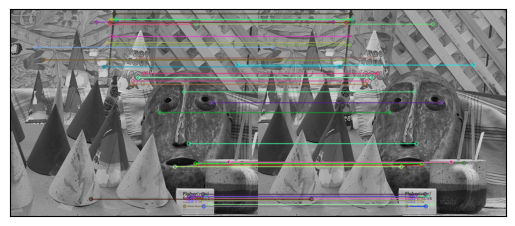

Estimated F:
 [[ 7.89242190e-10 -2.69219706e-07 -2.63078417e-05]
 [ 3.16470175e-07 -7.85832446e-08 -5.69575620e-03]
 [ 1.42096455e-05  5.69744295e-03  7.42023297e-04]]
Estimated F2:
 [[ 5.42449010e-22 -1.23244415e-18  9.72806011e-17]
 [ 1.13697313e-18 -1.00081842e-19 -1.94279439e-02]
 [-8.32171551e-17  1.94279439e-02 -8.88178420e-16]]
Estimated E:
 [[ 1.35616704e-04 -8.70245132e-02 -3.08676926e-02]
 [ 1.02290099e-01 -1.35140536e-02 -9.94147488e-01]
 [ 3.62506156e-02  9.95502951e-01 -1.25915897e-02]]
Estimated E2:
 [[-1.55831099e-14 -3.37216595e-13  1.46636588e-13]
 [ 3.19303152e-13  2.95413278e-14 -7.07106781e-01]
 [-1.59033325e-13  7.07106781e-01  4.69732476e-15]]


In [14]:
imaxe_esq = cv2.imread(stereodm_images_path+'cones_left.png',1)#, cv2.IMREAD_GRAYSCALE)
imaxe_der = cv2.imread(stereodm_images_path+'cones_right.png',1)# cv2.IMREAD_GRAYSCALE)


imaxe_esq=cv2.cvtColor(imaxe_esq, cv2.COLOR_BGR2RGB)
imaxe_der=cv2.cvtColor(imaxe_der, cv2.COLOR_BGR2RGB)

image1=imaxe_esq.copy()
image2=imaxe_der.copy()

#feature detection and matching

matches,key_features1,key_features2 = feature_match(image1,image2)
pt1,pt2  = feature_pairs(matches,key_features1,key_features2) 


'''
Estimating F matrix 
'''
pts1_F,pts2_F, F = ransac(pt1,pt2)
print("Estimated F:\n",F)


pts1 = np.int32(pt1)
pts2 = np.int32(pt2) 
##Implementation OpenCV
F2,mask=cv2.findFundamentalMat(pts1, pts2,cv2.FM_RANSAC, ransacReprojThreshold=3, confidence=0.99)#cv2.FM_8POINT)
#cv2.FM_RANSAC
print("Estimated F2:\n",F2)

# We select only inlier points
pts1_F2 = pts1[mask.ravel()==1]
pts2_F2 = pts2[mask.ravel()==1]



'''
Estimating E matrix
'''
E = estimate_E(k1,k1,F)
print("Estimated E:\n",E)

##Implementation OpenCV
E2,mask=cv2.findEssentialMat(pts1_F2, pts2_F2, k1, method=cv2.RANSAC, prob=0.99)#method=cv2.LMEDS, prob=0.99)
print("Estimated E2:\n",E2)



### Liñas Epipolares

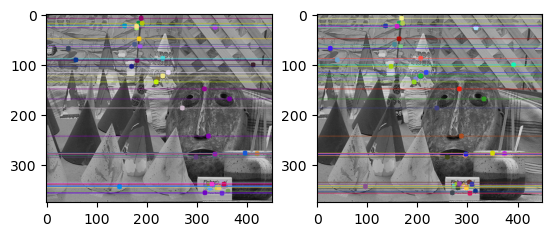

In [15]:
def drawlines(img1,img2,lines,pts1,pts2):
    ''' img1 - image on which we draw the epilines for the points in img2
        lines - corresponding epilines '''
    if len(img1.shape)==2:
        r,c = img1.shape
        img1 = cv2.cvtColor(img1,cv2.COLOR_GRAY2BGR)
        img2 = cv2.cvtColor(img2,cv2.COLOR_GRAY2BGR)
    else:
        r,c,_=img1.shape
    for r,pt1,pt2 in zip(lines,pts1,pts2):
        color = tuple(np.random.randint(0,255,3).tolist())
        x0,y0 = map(int, [0, -r[2]/r[1] ])
        x1,y1 = map(int, [c, -(r[2]+r[0]*c)/r[1] ])
        img1 = cv2.line(img1, (x0,y0), (x1,y1), color,1)
        pt1x,pt1y = map(int, [pt1[0],pt1[1]])
        pt2x,pt2y = map(int, [pt2[0],pt2[1]])
        img1 = cv2.circle(img1,(pt1x,pt1y),5,color,-1)
        img2 = cv2.circle(img2,(pt2x,pt2y),5,color,-1)
    return img1,img2


img1=image1.copy()
img2=image2.copy()

img1=cv2.cvtColor(img1,cv2.COLOR_BGR2GRAY)
img2=cv2.cvtColor(img2,cv2.COLOR_BGR2GRAY)


pts1=np.int32(pts1_F2)
pts2=np.int32(pts2_F2)


# Find epilines corresponding to points in right image (second image) and
# drawing its lines on left image
lines1 = cv2.computeCorrespondEpilines(pts2.reshape(-1,1,2), 2,F2)
lines1 = lines1.reshape(-1,3)

img5,img6 = drawlines(img1,img2,lines1,pts1,pts2)

# Find epilines corresponding to points in left image (first image) and
# drawing its lines on right image
lines2 = cv2.computeCorrespondEpilines(pts1.reshape(-1,1,2), 1,F2)
lines2 = lines2.reshape(-1,3)

img3,img4 = drawlines(img2,img1,lines2,pts2,pts1)

plt.subplot(121),plt.imshow(img5)
plt.subplot(122),plt.imshow(img3)
plt.show()

**Cálculo da posición relativa das cámaras dadas as correspondencias entre puntos e os parámetos intrínsecos**

In [16]:
def point_triangulation(k1,k2,pt1,pt2,R1,C1,R2,C2):
    points_3d = []

    I = np.identity(3)
    C1 = C1.reshape(3,1)
    C2 = C2.reshape(3,1)

    #calculating projection matrix P = K[R|T]
    P1 = np.dot(k1,np.dot(R1,np.hstack((I,-C1))))
    P2 = np.dot(k2,np.dot(R2,np.hstack((I,-C2))))
  
    #homogeneous coordinates for images
    xy = np.hstack((pt1,np.ones((len(pt1),1))))
    xy_cap = np.hstack((pt2,np.ones((len(pt1),1))))

    
    p1,p2,p3 = P1
    p1_cap, p2_cap,p3_cap = P2

    #constructing contraints matrix
    for i in range(len(xy)):
        A = []
        x = xy[i][0]
        y = xy[i][1]
        x_cap = xy_cap[i][0]
        y_cap = xy_cap[i][1] 
        
        A.append((y*p3) - p2)
        A.append((x*p3) - p1)
        
        A.append((y_cap*p3_cap)- p2_cap)
        A.append((x_cap*p3_cap) - p1_cap)

        A = np.array(A).reshape(4,4)

        _, _, v = np.linalg.svd(A)
        x_ = v[-1,:]
        x_ = x_/x_[-1]
        x_ = x_[:3]
        points_3d.append(x_)


    return points_3d

def linear_triangulation(R_Set,T_Set,pt1,pt2,k1,k2):
    R1_ = np.identity(3)
    T1_ = np.zeros((3,1))
    points_3d_set = []
    for i in range(len(R_Set)):
        points3d = point_triangulation(k1,k2,pt1,pt2,R1_,T1_,R_Set[i],T_Set[i])
        points_3d_set.append(points3d)

    return points_3d_set

def get_RTset(E):

    U, S, V = np.linalg.svd(E,full_matrices=True)
    W = np.array([[0,-1,0],[1,0,0],[0,0,1]])

    R1 = np.dot(U,np.dot(W,V))
    R2 = np.dot(U,np.dot(W,V))
    R3 = np.dot(U,np.dot(W.T,V))
    R4 = np.dot(U,np.dot(W.T,V))

    T1 = U[:,2]
    T2 = -U[:,2]
    T3 = U[:,2]
    T4 = -U[:,2]

    R = [R1,R2,R3,R4]
    T = [T1,T2,T3,T4]

    for i in range(len(R)):
        if (np.linalg.det(R[i]) < 0):
            R[i] = -R[i]
            T[i] = -T[i]

    return R, T

def compute_cheriality(pt,r3,t):
    count_depth = 0
    for xy in pt:
        if np.dot(r3,(xy-t)) > 0 and t[2] > 0:
            count_depth +=1
    return count_depth

def extract_pose(E,pt1,pt2,k1,k2):
    #get four rotation and translation matrices
    R_set, T_set = get_RTset(E)

    #get 3D points using triangulation
    pts_3d = linear_triangulation(R_set,T_set,pt1,pt2,k1,k2)
    threshold = 0
    index=0
    #Four sets are available for each possibility
    for i in range(len(R_set)):
        R = R_set[i]
        T = T_set[i]
        r3 = R[2]
        pt3d = pts_3d[i]

        #calculating which R satisfies the condition
        num_depth_positive = compute_cheriality(pt3d,r3,T)
        if num_depth_positive > threshold:
            index = i 
            threshold = num_depth_positive

    R_best = R_set[index]
    T_best = T_set[index]

    return R_best,T_best


'''
extract Pose
'''
R,T = extract_pose(E,pts1_F,pts2_F,k1,k2)
print("Rotation matrix:\n", R)
print("Translation:\n",T)


Rotation matrix:
 [[ 0.9798271  -0.06544978  0.18882579]
 [-0.06790866 -0.99766988  0.00657466]
 [ 0.18795549 -0.01926494 -0.98198859]]
Translation:
 [ 0.99572782 -0.03201373  0.08660958]


## Correspondencia de bloques para correspondencia estéreo densa

Dada unha configuración de cámaras estéreo horizontal, os puntos correspondentes para un par de imaxes estéreo rectificadas terían a mesma coordenada Y. Entón, como podemos atopar os puntos correspondentes?

A estratexia máis simple sería buscar unha correspondencia de bloques considerando a veciñanza dos píxeles a comparar entre as dúas imaxes. Partindo dun pixel nunha imaxes buscamos o correspondente na outra imaxe ao longo da liña epipolar (liña que neste caso sería a que ten a mesma coordenada Y).

Existen varias métricas que se poden empregar para cuantificar a semellanza, como a Suma de Diferenzas Absolutas (SAD), a Suma de Diferenzas ao Cadrado (SSD) e a Correlación Cruzada Normalizada (NCC).

No seguinte código úsase a medida SSD.

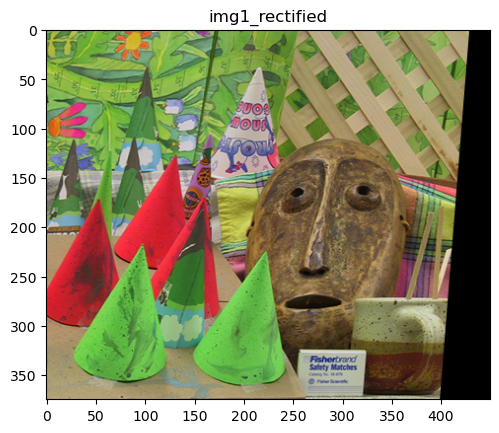

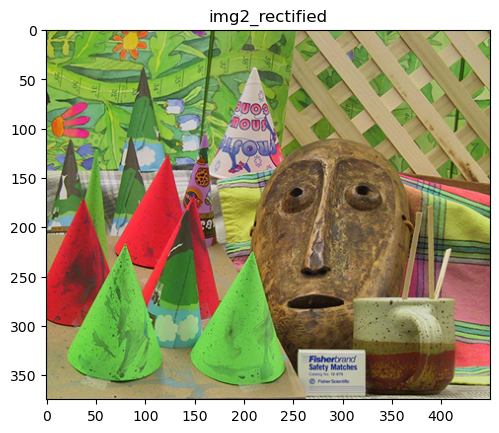

Detecting features
Feature Matching


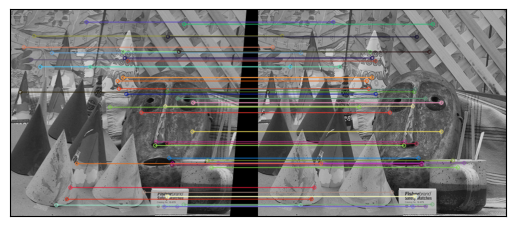

[[ 1.00000000e+00  1.18784962e-12 -5.71864138e-12]
 [ 1.18772173e-12 -1.00000000e+00  3.66105889e-12]
 [-5.71872443e-12 -3.66101706e-12 -1.00000000e+00]]
[ 1.00000000e+00 -2.30949583e-14  1.11599989e-13]
[[-3.27569465e-28  1.11622348e-13  2.31250653e-14]
 [ 5.83032442e-12  3.66072702e-12  1.00000000e+00]
 [ 1.21081669e-12 -1.00000000e+00  3.66092889e-12]]


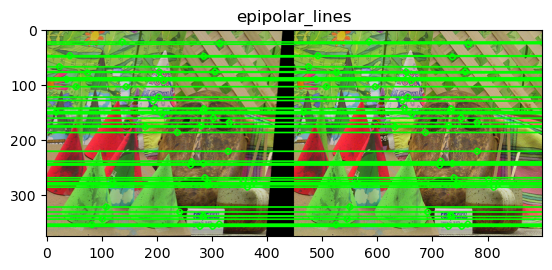

1.0


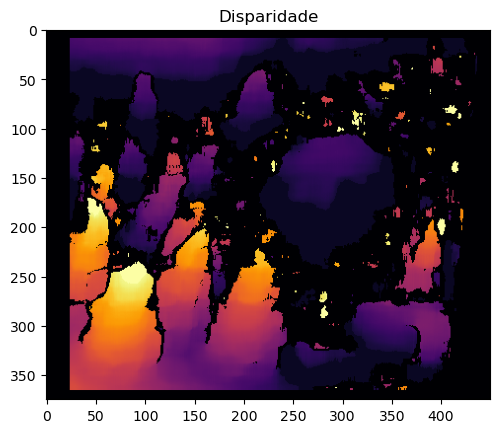

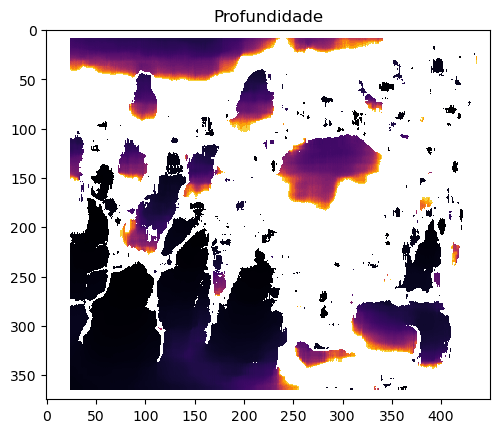

In [17]:
import numpy as np
import cv2
import glob
import matplotlib.pyplot as plt
#from tqdm import tqdm



def getCV2Disparity(imgLeft, imgRight,dispLevels=16,bSize=15):
    # Initialize the stereo block matching object 
    stereo = cv2.StereoBM_create(numDisparities=dispLevels, blockSize=bSize)

    # Compute the disparity image
    disparity = stereo.compute(imgLeft, imgRight).astype(np.float32)/16.0
    '''
    # Normalize the image for representation
    min = disparity.min()
    max = disparity.max()
    disparity = np.uint8(255 * (disparity - min) / (max - min))
    '''
    
    return disparity

def get_depth(disparidade,Q):
    

    # Calcular as coordenadas 3D (inclúe profundidade)
    puntos_3d = cv2.reprojectImageTo3D(disparidade,Q)

    # A profundidade é o valor Z das coordenadas 3D
    profundidade = puntos_3d[:, :, 2]

    # Opcional: eliminar valores infinitos ou negativos
    profundidade[profundidade <= 0] = np.nan
    
    return profundidade
    

def rectify(img1,img2,F,pts1,pts2):
    h1,w1 = img1.shape[:2]
    h2,w2 = img2.shape[:2]

    _,H1, H2 = cv2.stereoRectifyUncalibrated(np.float32(pts1), np.float32(pts2), F, imgSize=(w1, h1))
    img1_rectified = cv2.warpPerspective(img1, H1, (w1, h1))
    img2_rectified = cv2.warpPerspective(img2, H2, (w2, h2))

    H1_inv = np.linalg.inv(H1)
    H2_inv = np.linalg.inv(H2)
    F_rectified = np.dot(H2_inv.T, np.dot(F,H1_inv))

    return img1_rectified,img2_rectified,F_rectified

def draw_lines(lines_set,image,points):
    for line,pt in zip(lines_set,points):
        x0,y0 = map(int, [0, -line[2]/line[1] ])
        x1,y1 = map(int, [image.shape[1]-1, -line[2]/line[1] ])
        img = cv2.line(image, (x0,y0), (x1,y1), (0,255,0) ,2)
        img = cv2.circle(image, (int(pt[0]),int(pt[1])), 5, (0,255,0), 2)
    return img

def epipolar_lines(pts1_,pts2_,F,image1,image2):
    lines1_,lines2_ = [], []
    for i in range(len(pts1_)):
        p1 = np.array([pts1_[i,0], pts1_[i,1], 1])
        p2 = np.array([pts2_[i,0], pts2_[i,1], 1])
    
        lines1_.append(np.dot(F.T, p2))
        lines2_.append(np.dot(F,p1))
    img1 = draw_lines(lines1_,image1,pts1_)
    img2 = draw_lines(lines2_,image2,pts2_)

    out = np.hstack((img1, img2))

    plt.imshow(out)
    plt.title('epipolar_lines')
    plt.show()
    return lines1_,lines2_


'''
Rectify images anf F matrix
'''
img1_rectified,img2_rectified,F_rectified = rectify(image1,image2,F2,pts1_F2,pts2_F2)
plt.imshow(img1_rectified, cmap="gray")
plt.title('img1_rectified')
plt.show()
plt.imshow(img2_rectified, cmap="gray")
plt.title('img2_rectified')
plt.show()

matches,key_features1,key_features2 = feature_match(img1_rectified,img2_rectified)
pts1_R,pts2_R  = feature_pairs(matches,key_features1,key_features2)


E = estimate_E(k1,k1,F_rectified)
R,T = extract_pose(E,pts1_R,pts2_R,k1,k2)#Usando datos de k1 e k2 previos
print(R)  #comprobación de rectificación ben feita
print (T)
print(E)

lines1,lines2 = epipolar_lines(pts1_R,pts2_R,F_rectified,img1_rectified,img2_rectified)

gray1 = cv2.cvtColor(img1_rectified,cv2.COLOR_BGR2GRAY)#cv2.cvtColor(image1,cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(img2_rectified, cv2.COLOR_BGR2GRAY)#cv2.cvtColor(image2, cv2.COLOR_BGR2GRAY)


cx, cy=(120,120) #son os centros ópticos

f=1 #é a distancia focal arbitraria
#B=10 #é a distancia entre cámaras (baseline)

B=np.linalg.norm(T)
print(np.linalg.norm(B))


Q = np.array([
    [1, 0, 0, -cx],
    [0, 1, 0, -cy],
    [0, 0, 0,  f],
    [0, 0, 1/B, 0]
])

disparity_map = getCV2Disparity(gray1,gray2,16*1,19)
plt.imshow(disparity_map, cmap="inferno")
plt.title('Disparidade')
plt.show()#avefig("disparity.png")

depth_map = get_depth(disparity_map,Q)

plt.imshow(depth_map, cmap='inferno', interpolation='nearest')
plt.title('Profundidade')
plt.show()


## Correspondencia semiglobal
Na correspondencia semiglobal úsase unha estratexia mellorada: en lugar de buscar o mellor axuste nunha liña de epipolar, utilízase unha especie de optimización global. Agora a medida de correspondencia inclúe ademais da semellanza entre bloquesp un custo adicional que indica en que medidat os píxeles veciños teñan un valor de profundidade similar ou se desvíen significativamente.

In [18]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def calcular_disparidade(imaxe_esquerda, imaxe_dereita,dispLevels=16*6,bSize=5):
    # Imaxes en escala de grises
    img_esq = imaxe_esquerda
    img_der = imaxe_dereita

    # Crear o obxecto StereoSGBM
    min_disp = 0
    num_disp = dispLevels  # Ten que ser múltiplo de 16
    block_size = bSize

    stereo = cv2.StereoSGBM_create(
        minDisparity=min_disp,
        numDisparities=num_disp,
        blockSize=block_size,
        P1=8 * 3 * block_size**2,
        P2=32 * 3 * block_size**2,
        disp12MaxDiff=1,
        uniquenessRatio=10,
        speckleWindowSize=100,
        speckleRange=32
    )

    # Calcular o mapa de disparidade
    disparidade = stereo.compute(img_esq, img_der).astype(np.float32) / 16.0

    # Mostrar a disparidade (opcional)
    plt.imshow(disparidade, cmap='plasma')
    plt.colorbar(label='Disparidade')
    plt.title("Mapa de Disparidade")
    plt.show()

    return disparidade

In [19]:
def calcular_mapa_profundidade(disparidade, Q):

    # Calcular as coordenadas 3D (inclúe profundidade)
    puntos_3d = cv2.reprojectImageTo3D(disparidade, Q)

    # A profundidade é o valor Z das coordenadas 3D
    profundidade = puntos_3d[:, :, 2]

    # Opcional: eliminar valores infinitos ou negativos
    profundidade[profundidade <= 0] = np.nan

    # Mostrar o mapa de profundidade
    plt.imshow(profundidade, cmap='inferno')
    plt.colorbar(label='Profundidade (en unidades da cámara)')
    plt.title("Mapa de Profundidade")
    plt.show()

    return profundidade


In [20]:
cx, cy=(120,120) #son os centros ópticos

f=1 #é a distancia focal

B #é a distancia entre cámaras (baseline)


Q = np.array([
    [1, 0, 0, -cx],
    [0, 1, 0, -cy],
    [0, 0, 0,  f],
    [0, 0, 1/B, 0]
])

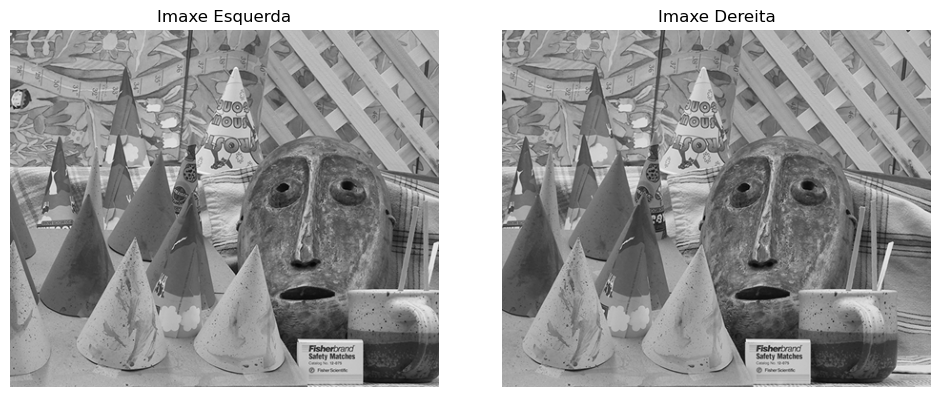

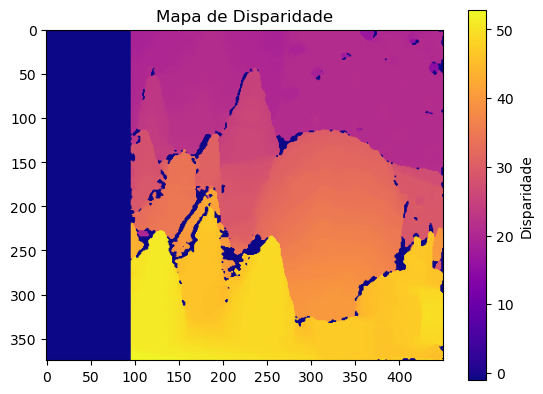

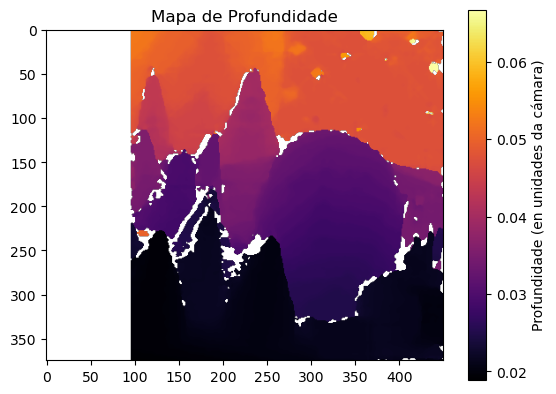

In [21]:
#imaxe_esq = cv2.imread('tsukuba_left.pgm', cv2.IMREAD_GRAYSCALE)
#imaxe_der = cv2.imread('tsukuba_right.pgm', cv2.IMREAD_GRAYSCALE)
imaxe_esq = cv2.imread(stereodm_images_path+'cones_left.png', cv2.IMREAD_GRAYSCALE)
imaxe_der = cv2.imread(stereodm_images_path+'cones_right.png', cv2.IMREAD_GRAYSCALE)

# Verificar que se cargaron correctamente
if imaxe_esq is None or imaxe_der is None:
    raise FileNotFoundError("Non se puideron cargar unha ou ambas as imaxes.")

# Amosar as imaxes
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(imaxe_esq, cmap='gray')
plt.title("Imaxe Esquerda")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(imaxe_der, cmap='gray')
plt.title("Imaxe Dereita")
plt.axis("off")

plt.tight_layout()
plt.show()



disparidade=calcular_disparidade(imaxe_esq, imaxe_der,16*6,5)
profundidade=calcular_mapa_profundidade(disparidade, Q)

---
---
### EXERCICIO 4.2 (x.x puntos):  Estimación de profundidade

Coa vosa propia cámara tomade dúas vistas dunha escena,evitanto áreas grandes de baixa textura, e facende unha estimación de profunidade.

---
---

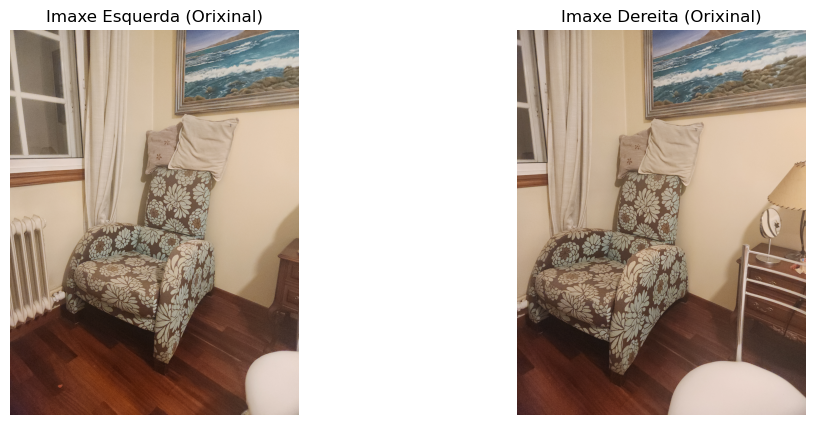

Detecting features
Feature Matching


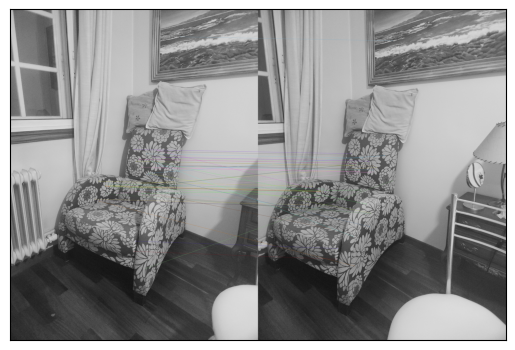

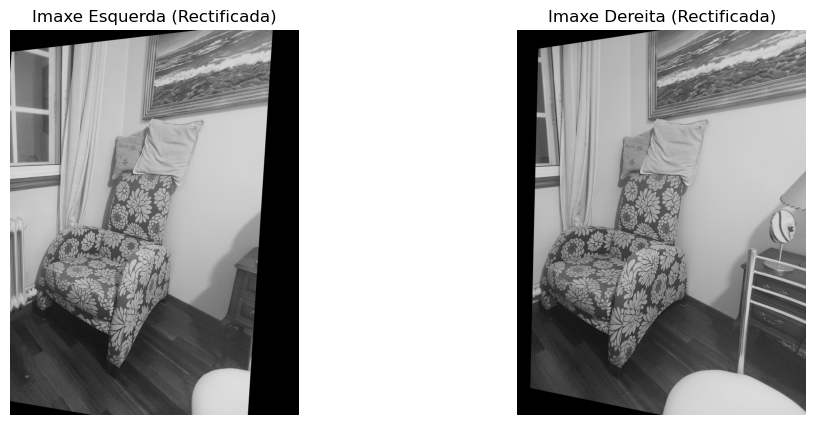

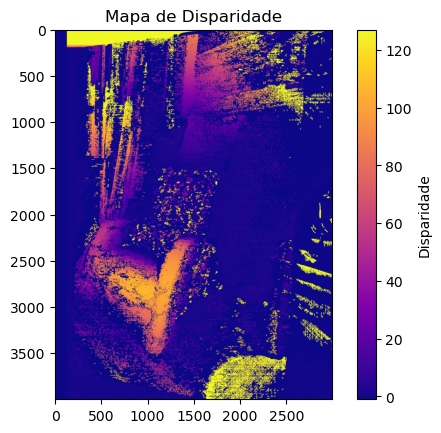

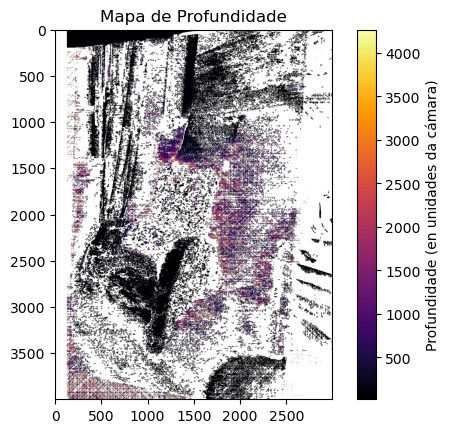

In [22]:
# Definir a ruta ás imaxes proporcionadas
imaxes_propias_path = './Images/Imaxes_propias/'

# Cargar as imaxes

imaxe_esq_propia = cv2.imread(imaxes_propias_path + 'esquerda.jpg')
imaxe_der_propia = cv2.imread(imaxes_propias_path + 'dereita.jpg')

imaxe_esq_propia_rgb = cv2.cvtColor(imaxe_esq_propia, cv2.COLOR_BGR2RGB)
imaxe_der_propia_rgb = cv2.cvtColor(imaxe_der_propia, cv2.COLOR_BGR2RGB)

imaxe_esq_gris = cv2.cvtColor(imaxe_esq_propia, cv2.COLOR_BGR2GRAY)
imaxe_der_gris = cv2.cvtColor(imaxe_der_propia, cv2.COLOR_BGR2GRAY)

# Amosar as imaxes orixinais
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(imaxe_esq_propia_rgb)
plt.title("Imaxe Esquerda (Orixinal)")
plt.axis("off")
plt.subplot(1, 2, 2)
plt.imshow(imaxe_der_propia_rgb)
plt.title("Imaxe Dereita (Orixinal)")
plt.axis("off")
plt.show()

# Detección e correspondencia de características
matches_propia, kp1_propia, kp2_propia = feature_match(imaxe_esq_propia, imaxe_der_propia, MAX_FEATURES=1000)
pt1_propia, pt2_propia = feature_pairs(matches_propia, kp1_propia, kp2_propia)

# Rectificación non calibrada
# Atopar a matriz fundamental e filtrar os puntos correspondentes
F_propia, mask_propia = cv2.findFundamentalMat(pt1_propia, pt2_propia, cv2.FM_RANSAC, ransacReprojThreshold=3, confidence=0.99)
pt1_inliers = pt1_propia[mask_propia.ravel() == 1]
pt2_inliers = pt2_propia[mask_propia.ravel() == 1]

# Rectificar as imaxes usando puntos correspondentes
h1, w1 = imaxe_esq_gris.shape
_, H1, H2 = cv2.stereoRectifyUncalibrated(pt1_inliers, pt2_inliers, F_propia, imgSize=(w1, h1))

# Aplicar a transformación homográfica
img_esq_rectificada = cv2.warpPerspective(imaxe_esq_gris, H1, (w1, h1))
img_der_rectificada = cv2.warpPerspective(imaxe_der_gris, H2, (w1, h1))

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(img_esq_rectificada, cmap='gray')
plt.title("Imaxe Esquerda (Rectificada)")
plt.axis("off")
plt.subplot(1, 2, 2)
plt.imshow(img_der_rectificada, cmap='gray')
plt.title("Imaxe Dereita (Rectificada)")
plt.axis("off")
plt.show()

# Cálculo do mapa de disparidade con SGBM
# Axustar os parámetros para estas imaxes pode mellorar o resultado
disparidade_propia = calcular_disparidade(img_esq_rectificada, img_der_rectificada, dispLevels=16*8, bSize=5)

# Cálculo do mapa de profundidade relativo
h, w = img_esq_rectificada.shape
f_estimado = 0.8 * w  # suposición común para a distancia focal
cx_estimado = w / 2
cy_estimado = h / 2
B_estimado = 1.0  # liña base de 1 para obter profundidade a escala

Q_propia = np.float32([
    [1, 0, 0, -cx_estimado],
    [0, 1, 0, -cy_estimado],
    [0, 0, 0, f_estimado],
    [0, 0, 1/B_estimado, 0]
])

profundidade_propia = calcular_mapa_profundidade(disparidade_propia, Q_propia)

**Imaxes**

Para estet exercicio fotografiei un sillón da miña casa tratando de que o cambio entre elas sexa horizontal.

**Feature Matching**

As liñas non son perfectamente horizontais, teñen unha lixeira inclinación.  
Isto é completamente normal xa que as fotos tomeinas a man e é case imposible manter a cámara exactamente no mesmo plano horizontal.  
Esta pequena desalineación vertical é solucionada pola rectificación.

Case todas as correspondencias atópanse na cadeira de brazos.   
A calidade da estimación de profundidade depende directamente da cantidade de textura na escena.  
Se a cadeira fose dunha soa cor lisa a posterios estimación da profundidade sería de peor calidade.

**Rectificación:**

O algoritmo "torce" as imaxes para forzar que as liñas epipolares se aliñen horizontalmente,  
o que é un requisito para os algoritmos de correspondencia densa como SGBM.

**Mapa de Disparidade:**

O mapa captura decentemente a estrutura da escena.
Partes da cadeira blanca son completamente amarelaas xa que é o mais cercano na escena.
As cores do sillón escurecen correctamente na súa parte frontal.

Obsérvanse zonas de ruído (toda a parte de atrás so sillón) e "buratos" en rexións con pouca textura (a parede lisa)
ou en zonas de oclusión (bordos da cadeira onde o fondo só é visible nunha das imaxes).
Confúndese o algoritmo co cuadro da parede.

**Mapa de Profundidade:**

Este mapa é inversamente proporcional ao mapa de disparidade.

A visualización confirma as observacións anteriores.  
O resultado, aínda que ruidoso, segmenta claramente a escena en primeiro plano e fondo.